In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [ ]:
import os
os.chdir("/content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/")

In [ ]:
%%capture
!pip install optuna torch plotly botorch

In [ ]:
# Import Packages
import os
import pandas as pd
import numpy as np
import datetime
import time
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import optuna
import matplotlib.pyplot as plt
import pickle as pkl
from sklearn.preprocessing import RobustScaler, MinMaxScaler
pd.set_option('display.max_columns', None)

In [ ]:
from src.preprocessing.data_preparation import DataPreparation
# from src.preprocessing.feature_scaling import robust_scaling, min_max_scaling
from src.model.base_model.quantile_tcn_model import QuantileTCNModel
from src.utils.helper_functions import get_approach
from src.utils.evaluate import evaluate_model
from src.utils.train import train, quantile_tcn_train
from src.utils.test import test, quantile_test
# from src.utils.postprocessing import process_data
from src.utils.metrics import performance_metrics
from src.utils.line_plotting import create_line_plot

In [ ]:
warnings.filterwarnings("ignore")
SEED = 1
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [ ]:
def robust_scaling(df, robust_cols, sin_cos_cols, column_name):
    scaled_df = df.copy()

    robust_scaler = RobustScaler()
    scaling_params = {}

    # this loop saved all the scaling params
    # for col in robust_cols:
    #     scaled_df[col] = robust_scaler.fit_transform(scaled_df[[col]])
    #     scaling_params[col] = (robust_scaler.center_[0], robust_scaler.scale_[0])

    for col in robust_cols:
        if col == column_name:
            scaled_df[col] = robust_scaler.fit_transform(scaled_df[[col]])
            scaling_params[col] = (robust_scaler.center_[0], robust_scaler.scale_[0])

    for col in sin_cos_cols:
        scaled_df[col + '_sin'] = np.sin(2 * np.pi * scaled_df[col] / scaled_df[col].max())
        scaled_df[col + '_cos'] = np.cos(2 * np.pi * scaled_df[col] / scaled_df[col].max())
        scaled_df.drop(col, axis=1, inplace=True)

    return scaled_df, scaling_params


def min_max_scaling(df, minmax_cols, sin_cos_cols, column_name):
    scaled_df = df.copy()
    scaler = MinMaxScaler()
    scaling_params = {}

    for col in minmax_cols:
        if col == column_name:
            scaling_params[col] = (scaled_df[col].min(), scaled_df[col].max())
        scaled_df[col] = scaler.fit_transform(scaled_df[[col]])

    for col in sin_cos_cols:
        scaled_df[col + '_sin'] = np.sin(2 * np.pi * scaled_df[col] / scaled_df[col].max())
        scaled_df[col + '_cos'] = np.cos(2 * np.pi * scaled_df[col] / scaled_df[col].max())
        scaled_df.drop(col, axis=1, inplace=True)

    # for col, (min_val, max_val) in scaling_params.items():
    #     scaled_df[f'{col}_min'] = min_val
    #     scaled_df[f'{col}_max'] = max_val

    return scaled_df, scaling_params

In [ ]:
def objective(trial, epochs):

    num_channels = trial.suggest_categorical('num_channels',
                                             [[2 ** i] * (j + 1) for i in range(4, 7) for j in range(0, 2)])
    kernel_size = trial.suggest_int('kernel_size', 2, 5)
    dropout = trial.suggest_float('dropout', 0.2, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])
    epochs = epochs

    train_loader = torch.utils.data.DataLoader(base_train_data, batch_size=batch_size, shuffle=False)
    val_loader = torch.utils.data.DataLoader(base_val_data, batch_size=batch_size, shuffle=False)
    test_loader = torch.utils.data.DataLoader(base_test_data, batch_size=batch_size, shuffle=False)

    # create the model
    model = QuantileTCNModel(input_size=base_x_train.shape[2], output_size=base_y_train.shape[1], num_channels=num_channels,
                kernel_size=kernel_size, dropout=dropout).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.MSELoss()

    train_loss = []
    val_loss = []

    for epoch in range(epochs):
        model.train()
        epoch_train_loss = []
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs.permute(0, 2, 1))
            loss = loss_fn(outputs, targets)
            loss.backward()
            optimizer.step()
            epoch_train_loss.append(loss.item())
        avg_train_loss = sum(epoch_train_loss) / len(epoch_train_loss)
        train_loss.append(avg_train_loss)

        model.eval()
        epoch_val_loss = []
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs.permute(0, 2, 1))
                loss = loss_fn(outputs, targets)
                epoch_val_loss.append(loss.item())
        avg_val_loss = sum(epoch_val_loss) / len(epoch_val_loss)
        val_loss.append(avg_val_loss)

        trial.report(avg_val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        trial.set_user_attr("num_channels", num_channels)
        trial.set_user_attr("kernel_size", kernel_size)
        trial.set_user_attr("dropout", dropout)
        trial.set_user_attr("learning_rate", learning_rate)
        trial.set_user_attr("batch_size", batch_size)
        trial.set_user_attr(f"train_loss_epoch_{epoch}", avg_train_loss)
        trial.set_user_attr(f"val_loss_epoch_{epoch}", avg_val_loss)

    return avg_val_loss

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")

Device: cpu



In [ ]:
if os.path.exists('/mnt/work/dkale/dkale_Colab/experiments_0.2/'):

    root_dir = '/mnt/work/dkale/dkale_Colab/experiments_0.2/'
else:
    root_dir = '/content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/'

current_date = datetime.datetime.now().strftime("%d%m%Y")
approach = get_approach(model_type=0)

In [ ]:
used_model = "TCN"
model_version = "1.0"
loss_function_name = "MSE"
optimization_technique = "OP"
github_issue_no = "4.0"

In [ ]:
# Define subdirectories
root_data_dir = root_dir + 'data/'
preprocessed_dir = root_data_dir + 'preprocessed/ACN/'
train_val_test_dir = root_data_dir + 'train_val_test/ACN/'
base_train_val_test_dir = train_val_test_dir + 'base_model'
result_dir = root_dir + 'result/'

# Base Directories
base_train_val_test_dir = train_val_test_dir + 'base_model/'
base_result_dir = result_dir + 'base_result/'
base_model_dir = base_result_dir + 'model/'
base_loss_metrics_dir = base_result_dir + 'loss_metrics'
base_permormance_metrics_dir = base_result_dir + 'performance_metrics'
base_trial_metrics_dir = base_result_dir + 'trial_metrics'
base_test_result_dir = base_result_dir + 'test_result'

In [ ]:
# Define parameters
HOURS = 24
PAST_DAYS = 7
FUTURE_DAYS = 1
N_PAST = HOURS * PAST_DAYS
N_FUTURE = HOURS * FUTURE_DAYS
EPOCHS = 2
PATIENCE = 3

N_TRIALS = 100

In [ ]:
study_name = f"Base Model, Used Model: {used_model}, Model Version: {model_version}, Loss Function: {loss_function_name}, Optimization Technique: {optimization_technique}, PAST DAYS: {PAST_DAYS} ---> FUTURE DAYS: {FUTURE_DAYS}"
common_file_name = f"{approach}_{used_model}_{model_version}_{loss_function_name}_{optimization_technique}_{github_issue_no}_{PAST_DAYS}.0_{FUTURE_DAYS}.0_{current_date}"

In [ ]:
base_df = pd.read_csv(f'{preprocessed_dir}finalVer03_caltech_acn_MultiSource.csv')

In [ ]:
base_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16550 entries, 0 to 16549
Columns: 144 entries, doneChargingTime to lag_2
dtypes: float64(117), int64(26), object(1)
memory usage: 18.2+ MB


In [ ]:
base_df.drop(columns = ['siteID'], axis = 1, inplace = True)

In [ ]:
base_df.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16550 entries, 0 to 16549
Data columns (total 143 columns):
 #    Column                                                   Dtype  
---   ------                                                   -----  
 0    doneChargingTime                                         object 
 1    energyPriceTotal                                         float64
 2    sitePublic                                               int64  
 3    sitePrivate                                              int64  
 4    EVSEcount                                                int64  
 5    EVSE_AV                                                  int64  
 6    EVSE_CC32                                                int64  
 7    EVSE_CC64                                                int64  
 8    EVSE_DX                                                  int64  
 9    EVSE_TWC                                                 int64  
 10   claimedCount                    

In [ ]:
minmax_cols = ['energyPriceTotal', 'EVSEcount', 'EVSE_AV', 'EVSE_CC32', 'EVSE_CC64', 'EVSE_DX', 'EVSE_TWC', 'claimedCount', 'unclaimedCount', 'NotAvailable', 'freeStationCount',
               'paidStationCount', '2 metre temperature', 'Total Precipitation', 'Water equivalent of accumulated snow depth (deprecated)', '2 metre relative humidity',
               '2 metre specific humidity', 'Surface pressure', 'Visibility', 'Total Cloud Cover', 'lag_1', 'lag_2', 'Smoothed_kWhDeliveredTotal'] + ['dayCategoryEF{}'.format(i)
               for i in range(1, 6)] + ['stationIDEF{}'.format(i) for i in range(1, 101)]

sin_cosine_cols = ['Hour_of_Day', 'Day_Of_Week', 'Day_Of_year', 'Month_Of_Year', 'Season']

base_df_scaled, base_df_scaling_params = min_max_scaling(df = base_df, minmax_cols=minmax_cols, sin_cos_cols=sin_cosine_cols, column_name='Smoothed_kWhDeliveredTotal')

In [ ]:
base_df_scaled.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16550 entries, 0 to 16549
Data columns (total 148 columns):
 #    Column                                                   Dtype  
---   ------                                                   -----  
 0    doneChargingTime                                         object 
 1    energyPriceTotal                                         float64
 2    sitePublic                                               int64  
 3    sitePrivate                                              int64  
 4    EVSEcount                                                float64
 5    EVSE_AV                                                  float64
 6    EVSE_CC32                                                float64
 7    EVSE_CC64                                                float64
 8    EVSE_DX                                                  float64
 9    EVSE_TWC                                                 float64
 10   claimedCount                    

In [ ]:
base_timestamp_list = base_df_scaled["doneChargingTime"].tolist()

In [ ]:
base_test_size = 90 * HOURS
base_val_size = 90 * HOURS

base_train_index = len(base_df_scaled) - base_test_size - base_val_size
base_val_index = base_train_index + base_val_size

base_train_df = base_df_scaled.iloc[:base_train_index]
base_val_df = base_df_scaled.iloc[base_train_index:base_val_index]
base_test_df = base_df_scaled.iloc[base_val_index:]

In [ ]:
# base_train_df.to_csv(
#     rf'{base_train_val_test_dir}acn_caltech_jpl_train_0.2_0.1_22_06_2023.csv',
#     index=False)
# base_val_df.to_csv(
#     rf'{base_train_val_test_dir}acn_caltech_jpl_val_0.2_0.1_22_06_2023.csv',
#     index=False)
# base_test_df.to_csv(
#     rf'{base_train_val_test_dir}acn_caltech_jpl_test_0.2_0.1_22_06_2023.csv',
#     index=False)

# BASE_TRAIN_FILE_NAME = rf'{base_train_val_test_dir}acn_caltech_jpl_train_0.2_0.1_22_06_2023.csv'
# BASE_VAL_FILE_NAME = rf'{base_train_val_test_dir}acn_caltech_jpl_val_0.2_0.1_22_06_2023.csv'
# BASETEST_FILE_NAME = rf'{base_train_val_test_dir}acn_caltech_jpl_test_0.2_0.1_22_06_2023.csv'

In [ ]:
dp = DataPreparation(n_future= N_FUTURE, n_past= N_PAST)

In [ ]:
base_x_train, base_y_train = dp.prepare_data(dataframe = base_train_df)
base_x_val, base_y_val = dp.prepare_data(dataframe = base_val_df)
base_x_test, base_y_test = dp.prepare_data(dataframe = base_test_df)

In [ ]:
base_x_train.shape, base_y_train.shape, base_x_val.shape, base_y_val.shape, base_x_test.shape, base_y_test.shape

((12039, 168, 147),
 (12039, 24),
 (1969, 168, 147),
 (1969, 24),
 (1969, 168, 147),
 (1969, 24))

In [ ]:
# base_x_train = base_x_train[:128]
# base_y_train = base_y_train[:128]
# base_x_val = base_x_val[:128]
# base_y_val = base_y_val[:128]
# base_x_test = base_x_test[:128]
# base_y_test = base_y_test[:128]

In [ ]:
base_train_data = TensorDataset(torch.from_numpy(base_x_train).float(), torch.from_numpy(base_y_train).float())
base_val_data = TensorDataset(torch.from_numpy(base_x_val).float(), torch.from_numpy(base_y_val).float())
base_test_data = TensorDataset(torch.from_numpy(base_x_test).float(), torch.from_numpy(base_y_test).float())

In [ ]:
base_train_loader = torch.utils.data.DataLoader(base_train_data, batch_size=64, shuffle=False)
base_val_loader = torch.utils.data.DataLoader(base_val_data, batch_size=64, shuffle=False)
base_test_loader = torch.utils.data.DataLoader(base_test_data, batch_size=64, shuffle=False)

In [ ]:
quantiles = [0.05, 0.5, 0.9]

In [ ]:
base_model = QuantileTCNModel(input_size=base_x_train.shape[2], output_size=base_y_train.shape[1], num_channels=[128]*5,
                kernel_size=3, dropout=0.02, quantiles=quantiles)

In [ ]:
epochs = 20
patience = 5
# base_optimizer = torch.optim.Adam(base_model.parameters(), lr=0.0001)
base_optimizer = torch.optim.Adam(base_model.parameters(), lr=0.0001, weight_decay=1e-4)

In [ ]:
reduction ='sum'

In [ ]:
base_train_loss, base_val_loss = quantile_tcn_train(device, base_model, base_optimizer, quantiles, reduction, base_train_loader, base_val_loader, epochs, patience, filename=None)

Training started........................

Epoch 1/20, Train Loss: 0.0950, Val Loss: 0.0824
Epoch 2/20, Train Loss: 0.0639, Val Loss: 0.0701
Epoch 3/20, Train Loss: 0.0565, Val Loss: 0.0646
Epoch 4/20, Train Loss: 0.0526, Val Loss: 0.0616
Epoch 5/20, Train Loss: 0.0501, Val Loss: 0.0590
Epoch 6/20, Train Loss: 0.0484, Val Loss: 0.0576
Epoch 7/20, Train Loss: 0.0470, Val Loss: 0.0563
Epoch 8/20, Train Loss: 0.0459, Val Loss: 0.0556
Epoch 9/20, Train Loss: 0.0450, Val Loss: 0.0550
Epoch 10/20, Train Loss: 0.0442, Val Loss: 0.0547
Epoch 11/20, Train Loss: 0.0435, Val Loss: 0.0544
Epoch 12/20, Train Loss: 0.0428, Val Loss: 0.0542
Epoch 13/20, Train Loss: 0.0423, Val Loss: 0.0542
Epoch 14/20, Train Loss: 0.0418, Val Loss: 0.0542
Epoch 15/20, Train Loss: 0.0413, Val Loss: 0.0543
Epoch 16/20, Train Loss: 0.0409, Val Loss: 0.0543
Epoch 17/20, Train Loss: 0.0405, Val Loss: 0.0542
Validation loss has not improved for 5 epochs, stopping training.



Train and validation losses have been saved to: 

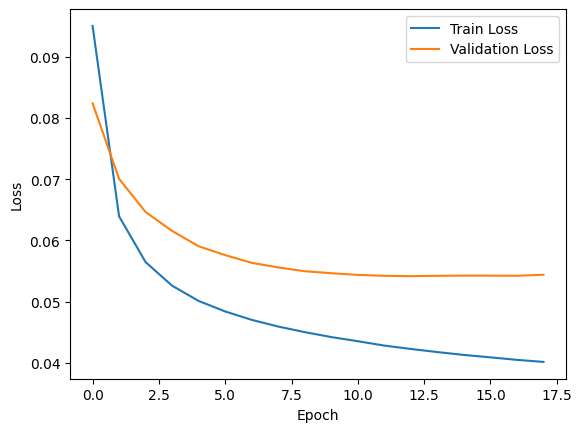

In [ ]:
plt.plot(base_train_loss, label='Train Loss')
plt.plot(base_val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
base_model_name = f'{common_file_name}_2.pt'
base_model_path = os.path.join(base_model_dir, base_model_name)

In [ ]:
# save the model to the specified path
if not os.path.exists(os.path.dirname(base_model_path)):
    os.makedirs(os.path.dirname(base_model_path))
torch.save(base_model.state_dict(), base_model_path)
print(f'The base trained model: {base_model_name} has been successfully saved: "{base_model_path}".\n')

The base trained model: TL_BM_TCN_1.0_MSE_OP_4.0_7.0_1.0_07102023_2.pt has been successfully saved: "/content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/base_result/model/TL_BM_TCN_1.0_MSE_OP_4.0_7.0_1.0_07102023_2.pt".



In [ ]:
if os.path.exists(base_model_path):
    base_model.load_state_dict(torch.load(base_model_path))
    base_test_loss, base_y_pred = quantile_test(device = device, model = base_model, test_loader=base_test_loader, quantiles = quantiles)
else:
    print(f"File not found at path: {base_model_path}\n")

Test Loss: 0.0174


In [ ]:
print(base_y_test.shape, base_y_pred.shape)

(1969, 24) (1969, 24, 3)


In [ ]:
base_y_test

array([[2.92686066e-04, 2.92686066e-06, 2.92686066e-08, ...,
        2.13065359e-01, 1.74251505e-01, 1.20471441e-01],
       [2.92686066e-06, 2.92686066e-08, 2.92686066e-10, ...,
        1.74251505e-01, 1.20471441e-01, 1.20471441e-03],
       [2.92686066e-08, 2.92686066e-10, 2.92686066e-12, ...,
        1.20471441e-01, 1.20471441e-03, 1.20471441e-05],
       ...,
       [8.00686567e-02, 5.57116075e-03, 5.57116075e-05, ...,
        1.57072511e-01, 9.64249885e-02, 1.11801672e-01],
       [5.57116075e-03, 5.57116075e-05, 5.57116075e-07, ...,
        9.64249885e-02, 1.11801672e-01, 1.04980746e-01],
       [5.57116075e-05, 5.57116075e-07, 5.57116075e-09, ...,
        1.11801672e-01, 1.04980746e-01, 2.01775931e-02]])

In [ ]:
def process_data(y_test, y_pred, quantiles, scaling_type, scaling_params, timestamp_list, train_df, val_df, scaled_df, n_past, n_future):

    y_pred_q1 = y_pred[:,:,0].reshape(y_pred.shape[0], -1)
    y_pred_q2 = y_pred[:,:,1].reshape(y_pred.shape[0], -1)
    y_pred_q3 = y_pred[:,:,2].reshape(y_pred.shape[0], -1)

    columns = ['t+' + str(i) for i in range(1, y_test.shape[1] + 1)]
    y_test_df = pd.DataFrame(y_test.reshape(y_test.shape[0], -1), columns=columns)
    y_pred_q1_df = pd.DataFrame(y_pred_q1.reshape(y_pred_q1.shape[0], -1), columns=columns)
    y_pred_q2_df = pd.DataFrame(y_pred_q2.reshape(y_pred_q2.shape[0], -1), columns=columns)
    y_pred_q3_df = pd.DataFrame(y_pred_q3.reshape(y_pred_q3.shape[0], -1), columns=columns)

    col_index = y_test_df.columns.get_loc('t+1')
    scaling_param = scaling_params['Smoothed_kWhDeliveredTotal']

    if scaling_type == 'robust':
        robust_center, robust_scale = np.array(scaling_param)
        y_test_df.iloc[:, col_index] = y_test_df.iloc[:, col_index] * robust_scale + robust_center
        y_pred_q1_df.iloc[:, col_index] = y_pred_q1_df.iloc[:, col_index] * robust_scale + robust_center
        y_pred_q2_df.iloc[:, col_index] = y_pred_q2_df.iloc[:, col_index] * robust_scale + robust_center
        y_pred_q3_df.iloc[:, col_index] = y_pred_q3_df.iloc[:, col_index] * robust_scale + robust_center

    elif scaling_type == 'min_max':
        min_value, max_value = np.array(scaling_param)
        y_test_df.iloc[:, col_index] = y_test_df.iloc[:, col_index] * (max_value - min_value) + min_value
        y_pred_q1_df.iloc[:, col_index] = y_pred_q1_df.iloc[:, col_index] * (max_value - min_value) + min_value
        y_pred_q2_df.iloc[:, col_index] = y_pred_q2_df.iloc[:, col_index] * (max_value - min_value) + min_value
        y_pred_q3_df.iloc[:, col_index] = y_pred_q3_df.iloc[:, col_index] * (max_value - min_value) + min_value


    y_test_df = y_test_df.iloc[:, 0]
    y_pred_q1_df = y_pred_q1_df.iloc[:, 0]
    y_pred_q2_df = y_pred_q2_df.iloc[:, 0]
    y_pred_q3_df = y_pred_q3_df.iloc[:, 0]
    y_test_org = y_test_df.copy()
    y_test_pred_q1 = y_pred_q1_df.copy()
    y_test_pred_q2 = y_pred_q2_df.copy()
    y_test_pred_q3 = y_pred_q3_df.copy()

    if y_test.shape[0] == 128:
        doneChargingTime_subset = timestamp_list[len(train_df)+len(val_df)+n_past:len(scaled_df)-(n_future)+1]
        doneChargingTime_subset = doneChargingTime_subset[:128]
    else:
        doneChargingTime_subset = timestamp_list[len(train_df)+len(val_df)+n_past:len(scaled_df)-(n_future)+1]
    result_df = pd.DataFrame({'y_test_org': y_test_org, 'y_test_pred_q1': y_test_pred_q1, 'y_test_pred_q2': y_test_pred_q2, 'y_test_pred_q3': y_test_pred_q3})
    result_df.insert(0, 'doneChargingTime', doneChargingTime_subset)
    result_df['doneChargingTime'] = pd.to_datetime(result_df['doneChargingTime'])
    result_df_daily_mean = result_df.copy()
    result_df_daily_mean = result_df_daily_mean.set_index('doneChargingTime')
    result_df_daily_mean = result_df_daily_mean.resample('D').mean()
    result_df_daily_mean = result_df_daily_mean.reset_index()

    result_df_daily_total = result_df.copy()
    result_df_daily_total = result_df_daily_total.set_index('doneChargingTime')
    result_df_daily_total = result_df_daily_total.resample('D').sum()
    result_df_daily_total = result_df_daily_total.reset_index()

    return result_df, result_df_daily_mean, result_df_daily_total

In [ ]:
base_result_df, base_result_df_daily_mean,  base_result_df_daily_total= process_data(
    y_test=base_y_test,
    y_pred=base_y_pred,
    quantiles = quantiles,
    scaling_type = 'min_max',
    scaling_params= base_df_scaling_params,
    timestamp_list=base_timestamp_list,
    train_df=base_train_df,
    val_df=base_val_df,
    scaled_df=base_df_scaled,
    n_past=N_PAST,
    n_future=N_FUTURE
)

In [ ]:
base_result_df

,doneChargingTime,y_test_org,y_test_pred_q1,y_test_pred_q2,y_test_pred_q3
0,2019-12-22 23:00:00,4.283029e-02,-1.906475,-0.435634,6.962369
1,2019-12-23 00:00:00,4.283029e-04,-3.097687,0.244824,5.040024
2,2019-12-23 01:00:00,4.283029e-06,-2.643626,0.479286,2.064693
3,2019-12-23 02:00:00,4.283029e-08,-4.833832,1.003821,3.022863
4,2019-12-23 03:00:00,4.283029e-10,-6.103179,0.441084,4.245727
...,...,...,...,...,...
1964,2020-03-13 19:00:00,3.355333e+00,-0.522030,7.767719,13.542569
1965,2020-03-13 20:00:00,1.169202e+01,-0.251552,6.800869,12.242518
1966,2020-03-13 21:00:00,1.171687e+01,1.275058,7.556094,13.251630
1967,2020-03-13 22:00:00,8.152573e-01,0.415965,5.225564,9.161921


In [ ]:
base_result_df_daily_total

,doneChargingTime,y_test_org,y_test_pred_q1,y_test_pred_q2,y_test_pred_q3
0,2019-12-22,0.042830,-1.906475,-0.435634,6.962369
1,2019-12-23,475.421667,161.218185,471.305603,649.667969
2,2019-12-24,323.514270,111.593842,365.152161,508.211517
3,2019-12-25,147.438151,-46.734871,150.334869,248.604111
4,2019-12-26,94.530013,-29.346169,157.698318,293.777771
...,...,...,...,...,...
78,2020-03-09,559.220877,135.990692,438.713898,623.446289
79,2020-03-10,180.398533,86.077850,307.813049,473.920868
80,2020-03-11,454.784059,127.705040,441.704529,592.634216
81,2020-03-12,398.477073,120.820663,402.146271,577.689514


In [ ]:
base_result_df_daily_mean

,doneChargingTime,y_test_org,y_test_pred_q1,y_test_pred_q2,y_test_pred_q3
0,2019-12-22,0.042830,-1.906475,-0.435634,6.962369
1,2019-12-23,19.809236,6.717424,19.637733,27.069498
2,2019-12-24,13.479761,4.649744,15.214673,21.175480
3,2019-12-25,6.143256,-1.947286,6.263953,10.358504
4,2019-12-26,3.938751,-1.222757,6.570763,12.240741
...,...,...,...,...,...
78,2020-03-09,23.300870,5.666279,18.279745,25.976929
79,2020-03-10,7.516606,3.586577,12.825543,19.746702
80,2020-03-11,18.949336,5.321043,18.404356,24.693092
81,2020-03-12,16.603211,5.034194,16.756094,24.070396


In [ ]:
def evaluate_PICP_WS(df, confidence):
    y_pred_upper = df['y_test_pred_q2']
    y_pred_lower = df['y_test_pred_q1']
    y_test = df['y_test_org']

    idx_oobl = np.where(y_test < y_pred_lower)[0]
    idx_oobu = np.where(y_test > y_pred_upper)[0]

    PICP = np.sum((y_test > y_pred_lower) & (y_test <= y_pred_upper)) / len(y_test) * 100

    WS = (np.sum(y_pred_upper - y_pred_lower) +
          np.sum(2 * (y_pred_lower[idx_oobl] - y_test[idx_oobl]) / confidence) +
          np.sum(2 * (y_test[idx_oobu] - y_pred_upper[idx_oobu]) / confidence)) / len(y_test)

    PINC = 1 - WS / (upper_bound - lower_bound)

    print ("PICP of testing set: {:.2f}%".format(PICP))
    print ("WS of testing set: {:.2f}".format(WS))
    print("PINC of testing set: {:.2f}%".format(PINC * 100))

    return PICP, PINC, WS

upper_bound = 0.95
lower_bound = 0.05
confidence = 1 - (upper_bound - lower_bound)
PICP, PINC, WS = evaluate_PICP_WS(base_result_df_daily, confidence)

PICP of testing set: 100.00%
WS of testing set: 20.58
PINC of testing set: -2186.38%


ref: https://gist.github.com/bshishov/5dc237f59f019b26145648e2124ca1c9
ref: https://www.geeksforgeeks.org/how-to-calculate-smape-in-python/

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt

mse1 = mean_squared_error(base_result_df['y_test_org'], base_result_df['y_test_pred_q3'])
rmse1 = sqrt(mse1)
nrmse1 = rmse1 / (base_result_df['y_test_org'].max() - base_result_df['y_test_org'].min())

mse2 = mean_squared_error(base_result_df['y_test_org'], base_result_df['y_test_pred_q2'])
rmse2 = sqrt(mse2)
nrmse2 = rmse2 / (base_result_df['y_test_org'].max() - base_result_df['y_test_org'].min())

smape1 = 100 * (2 * np.abs(base_result_df['y_test_org'] - base_result_df['y_test_pred_q3']) / (np.abs(base_result_df['y_test_org']) + np.abs(base_result_df['y_test_pred_q3']))).mean()
smape2 = 100 * (2 * np.abs(base_result_df['y_test_org'] - base_result_df['y_test_pred_q2']) / (np.abs(base_result_df['y_test_org']) + np.abs(base_result_df['y_test_pred_q2']))).mean()

y_test_org_diff = base_result_df['y_test_org'].diff(1).dropna()
mase1 = mean_absolute_error(base_result_df['y_test_org'], base_result_df['y_test_pred_q3']) / (np.abs(y_test_org_diff).mean())
mase2 = mean_absolute_error(base_result_df['y_test_org'], base_result_df['y_test_pred_q2']) / (np.abs(y_test_org_diff).mean())

error_summary = pd.DataFrame({
    'MSE1': [mse1],
    'MSE2': [mse2],
    'RMSE1': [rmse1],
    'RMSE2': [rmse2],
    'NRMSE1': [nrmse1],
    'NRMSE2': [nrmse2],
    'SMAPE1': [smape1],
    'SMAPE2': [smape2],
    'MASE1': [mase1],
    'MASE2': [mase2]
})

error_summary


,MSE1,MSE2,RMSE1,RMSE2,NRMSE1,NRMSE2,SMAPE1,SMAPE2,MASE1,MASE2
0,98.103947,94.939248,9.904744,9.743677,0.067685,0.066585,89.658409,94.74533,0.906355,0.797865


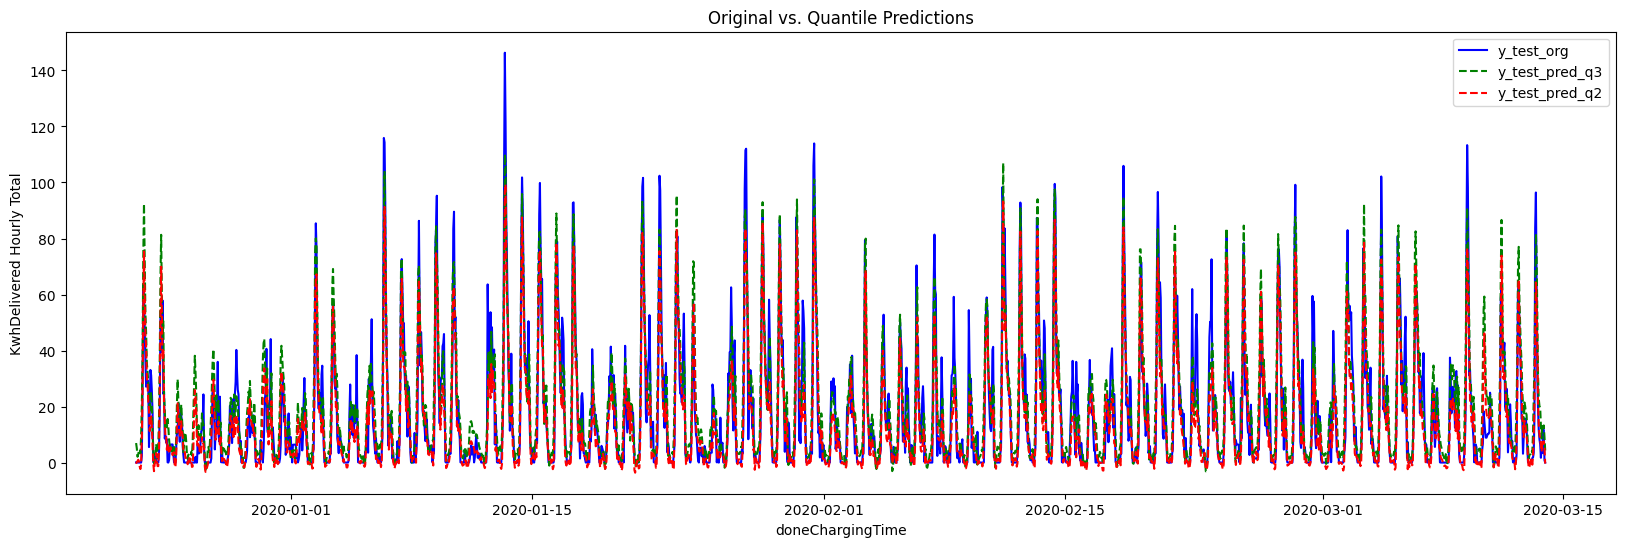

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(base_result_df['doneChargingTime'], base_result_df['y_test_org'], label='y_test_org', color='blue')
ax.plot(base_result_df['doneChargingTime'], base_result_df['y_test_pred_q3'], label='y_test_pred_q3', linestyle='--', color='green')
ax.plot(base_result_df['doneChargingTime'], base_result_df['y_test_pred_q2'], label='y_test_pred_q2', linestyle='--', color='red')
ax.set_xlabel('doneChargingTime')
ax.set_ylabel('KwhDelivered Hourly Total')
ax.set_title('Original vs. Quantile Predictions')
ax.legend()
plt.show()

In [ ]:
import plotly.express as px
fig = px.line(base_result_df, x='doneChargingTime', y=['y_test_org', 'y_test_pred_q3', 'y_test_pred_q2'],
              labels={'y_test_org': 'y_test_org', 'y_test_pred_q3': 'y_test_pred_q3', 'y_test_pred_q2': 'y_test_pred_q2'},
              title='Original vs. Quantile Predictions',
              line_shape='linear')

fig.update_traces(line_dash='dash')

fig.update_xaxes(title_text='doneChargingTime')
fig.update_yaxes(title_text='KwhDelivered Hourly Total')
fig.update_layout(legend=dict(x=0, y=1))
fig.show()

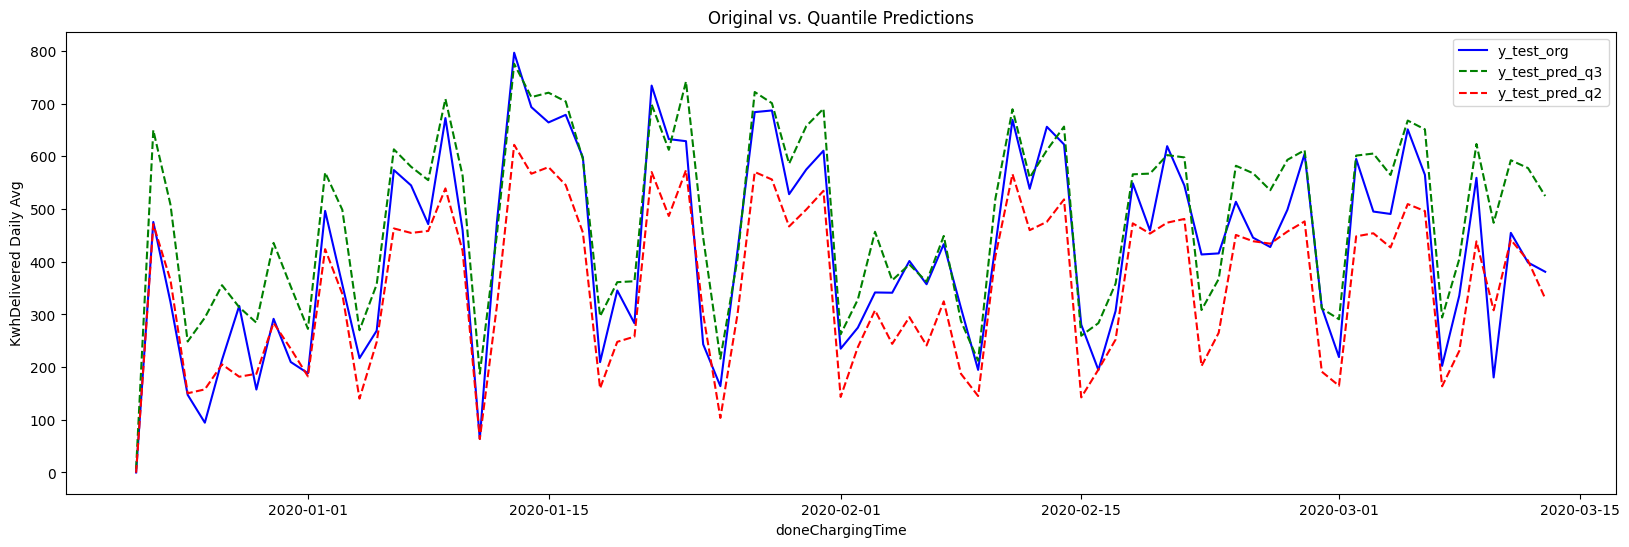

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(base_result_df_daily_total['doneChargingTime'], base_result_df_daily_total['y_test_org'], label='y_test_org', color='blue')
ax.plot(base_result_df_daily_total['doneChargingTime'], base_result_df_daily_total['y_test_pred_q3'], label='y_test_pred_q3', linestyle='--', color='green')
ax.plot(base_result_df_daily_total['doneChargingTime'], base_result_df_daily_total['y_test_pred_q2'], label='y_test_pred_q2', linestyle='--', color='red')
ax.set_xlabel('doneChargingTime')
ax.set_ylabel('KwhDelivered Daily Avg')
ax.set_title('Original vs. Quantile Predictions')
ax.legend()
plt.show()

In [ ]:
import plotly.express as px
fig = px.line(base_result_df_daily_total, x='doneChargingTime', y=['y_test_org', 'y_test_pred_q3', 'y_test_pred_q2'],
              labels={'y_test_org': 'y_test_org', 'y_test_pred_q3': 'y_test_pred_q3', 'y_test_pred_q2': 'y_test_pred_q2'},
              title='Original vs. Quantile Predictions',
              line_shape='linear')

fig.update_traces(line_dash='dash')

fig.update_xaxes(title_text='doneChargingTime')
fig.update_yaxes(title_text='KwhDelivered Daily Avg')
fig.update_layout(legend=dict(x=0, y=1))
fig.show()

In [ ]:
import plotly.express as px
fig = px.line(base_result_df_daily_mean, x='doneChargingTime', y=['y_test_org', 'y_test_pred_q3', 'y_test_pred_q2'],
              labels={'y_test_org': 'y_test_org', 'y_test_pred_q3': 'y_test_pred_q3', 'y_test_pred_q2': 'y_test_pred_q2'},
              title='Original vs. Quantile Predictions',
              line_shape='linear')

fig.update_traces(line_dash='dash')

fig.update_xaxes(title_text='doneChargingTime')
fig.update_yaxes(title_text='KwhDelivered Daily Avg')
fig.update_layout(legend=dict(x=0, y=1))
fig.show()

In [ ]:
------------------------ DEEP TCN ---------------------------------------

In [ ]:
import torch
import torch.nn as nn

class ResidualTCNBlock(nn.Module):
    def __init__(self, input_size, output_size, kernel_size, dilation):
        super(ResidualTCNBlock, self).__init__()
        self.conv1 = nn.Conv1d(input_size, output_size, kernel_size, dilation=dilation, padding=(kernel_size - 1) * dilation)
        self.bn1 = nn.BatchNorm1d(output_size)
        self.conv2 = nn.Conv1d(output_size, output_size, kernel_size, dilation=dilation, padding=(kernel_size - 1) * dilation)
        self.bn2 = nn.BatchNorm1d(output_size)

    def forward(self, x):
        residual = x
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = torch.relu(out + residual)
        return out

class TCN(nn.Module):
    def __init__(self, input_size, output_size, num_channels, kernel_size, dilations):
        super(TCN, self).__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.num_channels = num_channels
        self.kernel_size = kernel_size
        self.dilations = dilations

        layers = []
        for dilation in self.dilations:
            layers.append(ResidualTCNBlock(input_size, num_channels, kernel_size, dilation))
        self.tcn = nn.Sequential(*layers)

        self.output_layer = nn.Sequential(
            nn.Conv1d(num_channels, output_size, kernel_size=1),
            nn.BatchNorm1d(output_size),
            nn.ReLU()
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.tcn(x)
        x = self.output_layer(x)
        x = x.permute(0, 2, 1)

        return x